In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

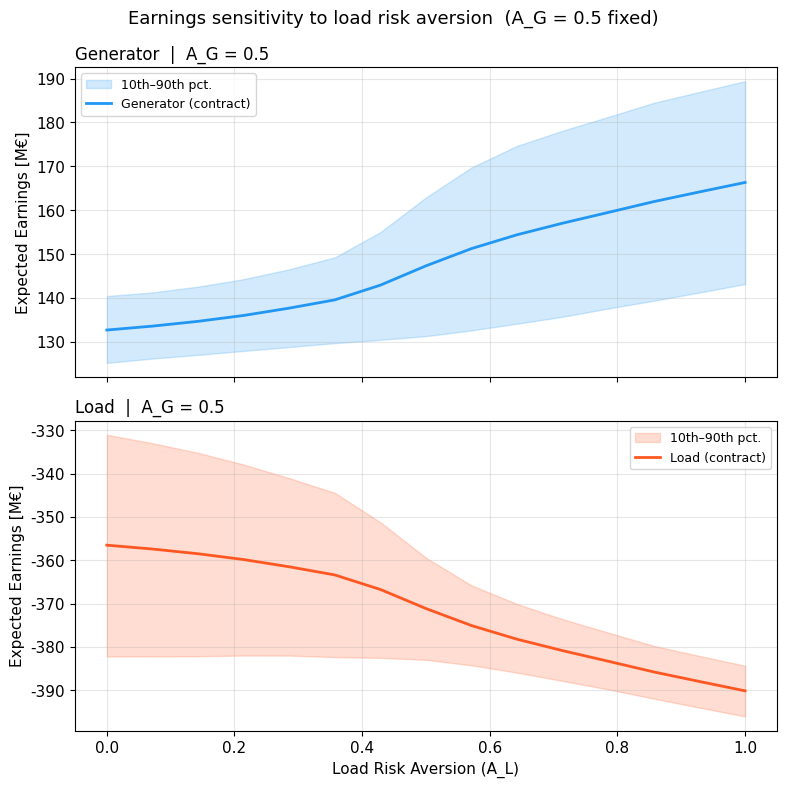

Saved → results/earnings_risk_aversion_lineplot.png


In [30]:
# ── Earnings line plot: fixed A_G = 0.5, vary A_L ────────────────────────────
# Reads scenario-level earnings grids, applies non-uniform scenario weights,
# and plots weighted mean + 10th–90th percentile band for G and L,
# with counterfactual (no-contract) as a dashed overlay.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── helpers ───────────────────────────────────────────────────────────────────
def weighted_quantile(values: np.ndarray, weights: np.ndarray, q: float) -> float:
    """Weighted quantile via sorted cumulative weight interpolation."""
    sorter = np.argsort(values)
    sv, sw = values[sorter], weights[sorter]
    sw = sw / sw.sum()
    return float(np.interp(q, np.cumsum(sw), sv))


def summarise(df_raw: pd.DataFrame, probs: np.ndarray, A_G_fixed: float = 0.5) -> pd.DataFrame:
    """
    Slice columns where A_G ≈ A_G_fixed, then for each A_L value compute
    weighted mean, 10th and 90th percentile across 2000 scenarios.
    Returns a DataFrame with columns: A_L, mean, q10, q90.
    """
    ag_vals = df_raw.columns.get_level_values(0).astype(float)
    sub = df_raw.loc[:, np.isclose(ag_vals, A_G_fixed)]
    al_vals = sub.columns.get_level_values(1).astype(float)

    records = [
        {
            "A_L": al,
            "mean": float(np.average(sub[col].values.astype(float), weights=probs)),
            "q10":  weighted_quantile(sub[col].values.astype(float), probs, 0.10),
            "q90":  weighted_quantile(sub[col].values.astype(float), probs, 0.90),
        }
        for col, al in zip(sub.columns, al_vals)
    ]
    return pd.DataFrame(records).sort_values("A_L").reset_index(drop=True)


# ── load data ─────────────────────────────────────────────────────────────────
BASE = "sensitivity/default_baseload_risk_aversion"
PROB_PATH = "../data/processed/scenarios_reduced_2000/probabilities_scenarios_reduced_20y_2000s.csv"

probs = pd.read_csv(PROB_PATH).values.flatten()
probs = probs / probs.sum()   # normalise (should already sum to 1)

def load_earnings(fname: str) -> pd.DataFrame:
    return pd.read_csv(f"{BASE}/{fname}", header=[0, 1], index_col=0)

A_G_FIXED = 0.5

sum_G    = summarise(load_earnings("earnings_G.csv"),    probs, A_G_FIXED)
sum_L    = summarise(load_earnings("earnings_L.csv"),    probs, A_G_FIXED)
# ── plot ──────────────────────────────────────────────────────────────────────
C_G,  C_G_dark = "#2196F3", "#0D47A1"   # blue  — Generator
C_L,  C_L_dark = "#FF5722", "#BF360C"   # red   — Load

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
fig.subplots_adjust(hspace=0.06)

for ax, summ, color, color_dark, label in [
    (axes[0], sum_G,  C_G,  C_G_dark,  "Generator"),
    (axes[1], sum_L,  C_L,  C_L_dark,  "Load"),
]:
    x = summ["A_L"].values
    ax.fill_between(x, summ["q10"], summ["q90"],
                    color=color, alpha=0.20, label="10th–90th pct.")
    ax.plot(x, summ["mean"],
            color=color, linewidth=2.0, label=f"{label} (contract)")
    ax.set_ylabel("Expected Earnings [M€]", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{label}  |  A_G = {A_G_FIXED}", fontsize=12, loc="left")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

axes[1].set_xlabel("Load Risk Aversion (A_L)", fontsize=11)
fig.suptitle(f"Earnings sensitivity to load risk aversion  (A_G = {A_G_FIXED} fixed)",
             fontsize=13)
plt.tight_layout()
plt.savefig("earnings_risk_aversion_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/earnings_risk_aversion_lineplot.png")

---
## Extreme-value variants
*Each cell below requires the earnings cell above to have been run first (defines `weighted_quantile`, `summarise`, `load_earnings`, `probs`, `A_G_FIXED`, colour constants).*

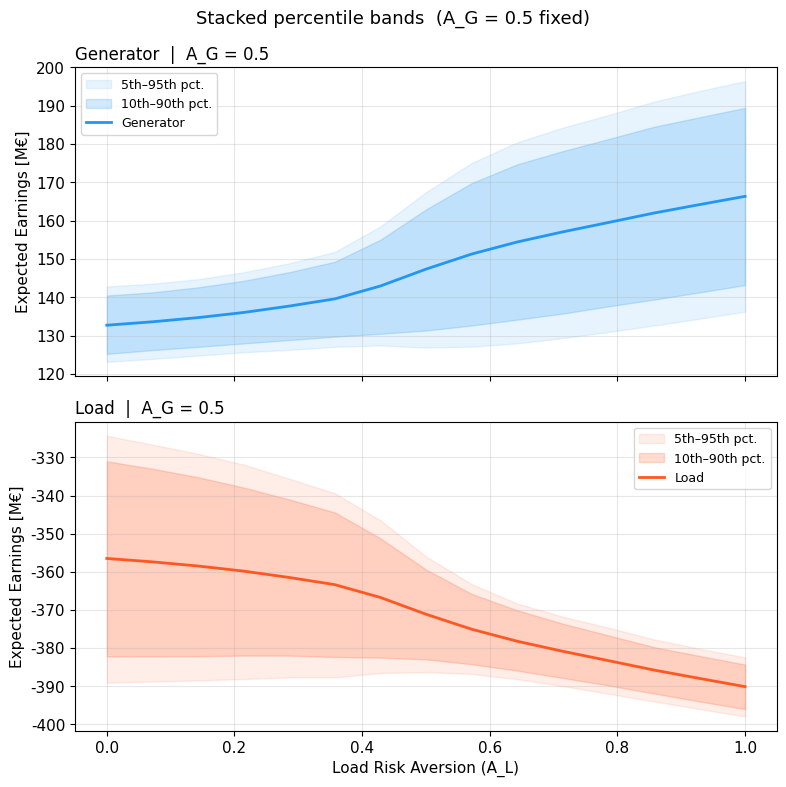

Saved → results/earnings_stacked_bands.png


In [31]:
# ── Plot A: Stacked percentile bands (5–95 outer + 10–90 inner) ───────────────
import matplotlib.ticker as mticker

def summarise_ext(df_raw, probs, A_G_fixed=0.5):
    """Extends summarise() with q05 and q95 columns."""
    ag_vals = df_raw.columns.get_level_values(0).astype(float)
    sub = df_raw.loc[:, np.isclose(ag_vals, A_G_fixed)]
    al_vals = sub.columns.get_level_values(1).astype(float)
    records = [
        {
            "A_L":  al,
            "mean": float(np.average(sub[col].values.astype(float), weights=probs)),
            "q05":  weighted_quantile(sub[col].values.astype(float), probs, 0.05),
            "q10":  weighted_quantile(sub[col].values.astype(float), probs, 0.10),
            "q90":  weighted_quantile(sub[col].values.astype(float), probs, 0.90),
            "q95":  weighted_quantile(sub[col].values.astype(float), probs, 0.95),
        }
        for col, al in zip(sub.columns, al_vals)
    ]
    return pd.DataFrame(records).sort_values("A_L").reset_index(drop=True)

sum_G_ext = summarise_ext(load_earnings("earnings_G.csv"), probs, A_G_FIXED)
sum_L_ext = summarise_ext(load_earnings("earnings_L.csv"), probs, A_G_FIXED)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
fig.subplots_adjust(hspace=0.06)

for ax, summ, color, label in [
    (axes[0], sum_G_ext, C_G, "Generator"),
    (axes[1], sum_L_ext, C_L, "Load"),
]:
    x = summ["A_L"].values
    ax.fill_between(x, summ["q05"], summ["q95"],
                    color=color, alpha=0.10, label="5th–95th pct.")
    ax.fill_between(x, summ["q10"], summ["q90"],
                    color=color, alpha=0.20, label="10th–90th pct.")
    ax.plot(x, summ["mean"],
            color=color, linewidth=2.0, label=f"{label}")
    ax.set_ylabel("Expected Earnings [M€]", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{label}  |  A_G = {A_G_FIXED}", fontsize=12, loc="left")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

axes[1].set_xlabel("Load Risk Aversion (A_L)", fontsize=11)
fig.suptitle(f"Stacked percentile bands  (A_G = {A_G_FIXED} fixed)", fontsize=13)
plt.tight_layout()
plt.savefig("earnings_stacked_bands.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/earnings_stacked_bands.png")

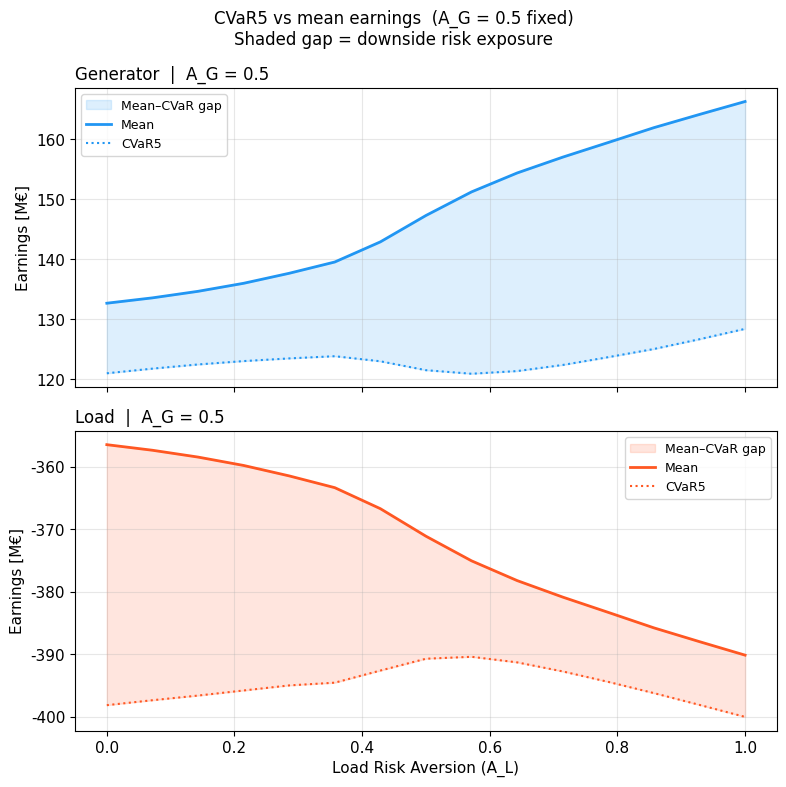

Saved → results/earnings_cvar5_lineplot.png


In [32]:
# ── Plot D: CVaR (Expected Shortfall) vs mean ─────────────────────────────────
# CVaR_α = expected earnings in the worst α% of scenarios (left tail).
# Directly tied to the A_G / A_L risk-aversion objective in the model.

CVAR_ALPHA = 0.05   # ← change to 0.05 for tighter tail if desired


def weighted_cvar(values: np.ndarray, weights: np.ndarray, alpha: float) -> float:
    """Weighted CVaR (Expected Shortfall) at level alpha."""
    q = weighted_quantile(values, weights, alpha)
    mask = values <= q
    w_tail = weights[mask]
    return float(np.average(values[mask], weights=w_tail)) if w_tail.sum() > 0 else np.nan


def summarise_cvar(df_raw, probs, A_G_fixed=0.5, alpha=0.10):
    ag_vals = df_raw.columns.get_level_values(0).astype(float)
    sub = df_raw.loc[:, np.isclose(ag_vals, A_G_fixed)]
    al_vals = sub.columns.get_level_values(1).astype(float)
    records = [
        {
            "A_L":  al,
            "mean": float(np.average(sub[col].values.astype(float), weights=probs)),
            "cvar": weighted_cvar(sub[col].values.astype(float), probs, alpha),
        }
        for col, al in zip(sub.columns, al_vals)
    ]
    return pd.DataFrame(records).sort_values("A_L").reset_index(drop=True)


sum_G_cv = summarise_cvar(load_earnings("earnings_G.csv"), probs, A_G_FIXED, CVAR_ALPHA)
sum_L_cv = summarise_cvar(load_earnings("earnings_L.csv"), probs, A_G_FIXED, CVAR_ALPHA)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
fig.subplots_adjust(hspace=0.06)

alpha_pct = int(CVAR_ALPHA * 100)

for ax, summ, color, label in [
    (axes[0], sum_G_cv, C_G, "Generator"),
    (axes[1], sum_L_cv, C_L, "Load"),
]:
    x = summ["A_L"].values

    # Shaded gap between CVaR and mean shows the risk premium visually
    ax.fill_between(x, summ["cvar"], summ["mean"],
                    color=color, alpha=0.15, label="Mean–CVaR gap")
    ax.plot(x, summ["mean"],
            color=color, linewidth=2.0, label="Mean")
    ax.plot(x, summ["cvar"],
            color=color, linewidth=1.5, linestyle=":",
            label=f"CVaR{alpha_pct}")

    ax.set_ylabel("Earnings [M€]", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{label}  |  A_G = {A_G_FIXED}", fontsize=12, loc="left")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

axes[1].set_xlabel("Load Risk Aversion (A_L)", fontsize=11)
fig.suptitle(
    f"CVaR{alpha_pct} vs mean earnings  (A_G = {A_G_FIXED} fixed)\n"
    f"Shaded gap = downside risk exposure",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f"earnings_cvar{alpha_pct}_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → results/earnings_cvar{alpha_pct}_lineplot.png")

In [ ]:
# ── Contract parameters: S and M sensitivity (heatmap + A_G slices) ──────────
# Produces a 2×2 figure:
#   (a) heatmap of S [EUR/MWh]    (b) line slices of S at 3 A_G values
#   (c) heatmap of M [MW]         (d) line slices of M at 3 A_G values
# Requires BASE to be defined (run base cell f7f8d8e5 first).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── data ──────────────────────────────────────────────────────────────────────
df_S = pd.read_csv(f"{BASE}/grid_S_EUR_MWh.csv", index_col=0)
df_M = pd.read_csv(f"{BASE}/grid_M_MWh_h.csv",   index_col=0)

ag_vals = df_S.index.astype(float).values    # shape (15,)
al_vals = df_S.columns.astype(float).values  # shape (15,)

# ── slice config ──────────────────────────────────────────────────────────────
# Target A_G values; nearest grid points are 4/14≈0.2857, 7/14=0.5, 11/14≈0.7857
AG_TARGETS  = [0.25,                0.50,    0.75              ]
AG_LABELS   = [r"$\approx$0.25",   "0.50",  r"$\approx$0.75"  ]
COLORS_S    = ["#90CAF9", "#1E88E5", "#0D47A1"]  # light → dark blue
COLORS_M    = ["#FFCC80", "#FB8C00", "#BF360C"]  # light → dark orange

# Nearest grid indices for each target
ag_idxs = [int(np.argmin(np.abs(ag_vals - t))) for t in AG_TARGETS]

# ── style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({"font.size": 11, "axes.labelsize": 11, "legend.fontsize": 9})

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.subplots_adjust(hspace=0.40, wspace=0.45)

AL_mesh, AG_mesh = np.meshgrid(al_vals, ag_vals)  # both shape (15,15)
_AL_TICKS = np.linspace(0, 1, 11)                 # 0.0, 0.1, …, 1.0

def add_heatmap(ax, data, cmap, unit_label, panel_label, slice_colors):
    """Render pcolormesh heatmap with colorbar."""
    pcm = ax.pcolormesh(AL_mesh, AG_mesh, data, cmap=cmap, shading="nearest")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(unit_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)
    ax.set_xticks(_AL_TICKS)
    ax.set_xlabel("Load risk aversion $A_L$", fontsize=10)
    ax.set_ylabel("Generator risk aversion $A_G$", fontsize=10)
    ax.set_title(panel_label, loc="left", fontsize=11)
    ax.tick_params(labelsize=9)

def add_lineplot(ax, data, colors, unit_label, panel_label):
    """Render three A_G slice lines."""
    for idx, color, lbl in zip(ag_idxs, colors, AG_LABELS):
        ax.plot(al_vals, data.iloc[idx].values,
                color=color, linewidth=1.8, label=f"$A_G$ = {lbl}")
    ax.set_xticks(_AL_TICKS)
    ax.set_xlabel("Load risk aversion $A_L$", fontsize=10)
    ax.set_ylabel(unit_label, fontsize=10)
    ax.set_title(panel_label, loc="left", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=9)

# ── panels ────────────────────────────────────────────────────────────────────
add_heatmap( axes[0, 0], df_S.values, "viridis", "EUR/MWh",
             "(a)  Strike price $S$",       COLORS_S)
add_lineplot(axes[0, 1], df_S,         COLORS_S, "Strike price $S$ [EUR/MWh]",
             "(b)  $S$ — slices")

add_heatmap( axes[1, 0], df_M.values, "plasma",  "MW",
             "(c)  Contract volume $M$",    COLORS_M)
add_lineplot(axes[1, 1], df_M,         COLORS_M, "Contract volume $M$ [MW]",
             "(d)  $M$ — slices")

plt.savefig("contract_params_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> results/contract_params_sensitivity.png")

In [34]:
# ── Scenario input summary statistics ────────────────────────────────────────
# Probability-weighted mean and std for price, production, and capture rate,
# collapsed to per-scenario annual means then aggregated across scenarios.
# No dependency on BASE or any earlier cell.
import numpy as np
import pandas as pd

SCEN_PATH = "../data/processed/scenarios_reduced_2000"
_YEARS, _N = 20, 2000

def _read_scen(kind):
    return pd.read_csv(
        f"{SCEN_PATH}/{kind}_scenarios_reduced_{_YEARS}y_{_N}s.csv",
        index_col=0,
    ).to_numpy()

_price = _read_scen("price")        # (20, 2000)  kEUR/MWh
_prod  = _read_scen("production")   # (20, 2000)  GWh/year
_cr    = _read_scen("capture_rate") # (20, 2000)  dimensionless

_prob  = pd.read_csv(
    f"{SCEN_PATH}/probabilities_scenarios_reduced_{_YEARS}y_{_N}s.csv"
)["Probability"].to_numpy()
_prob  = _prob / _prob.sum()

def _wt_mean_std(X, prob):
    """Probability-weighted mean and std of per-scenario annual means."""
    xs  = X.mean(axis=0)                    # annual mean per scenario, shape (S,)
    mu  = float((prob * xs).sum())
    sig = float(np.sqrt((prob * (xs - mu) ** 2).sum()))
    return mu, sig

rows = {
    "Price [EUR/MWh]":     _wt_mean_std(_price * 1e3,        _prob),  # kEUR/MWh -> EUR/MWh
    "Production [GWh/yr]": _wt_mean_std(_prod,               _prob),
    "Production [MW]":     _wt_mean_std(_prod * 1e3 / 8760,  _prob),  # GWh/yr -> MW
    "Capture rate":        _wt_mean_std(_cr,                 _prob),
}

summary = (
    pd.DataFrame(rows, index=["Mean", "Std"])
    .T
    .round(2)
)

display(summary)
summary.to_csv("scenario_summary_stats.csv")
print("Saved -> scenario_summary_stats.csv")

# ── LaTeX snippet ─────────────────────────────────────────────────────────────
_lines = [
    r"\begin{tabular}{lrr}",
    r"\toprule",
    r"Variable & Mean & Std \\",
    r"\midrule",
    *[rf"{var} & {row['Mean']:.2f} & {row['Std']:.2f} \\" for var, row in summary.iterrows()],
    r"\bottomrule",
    r"\end{tabular}",
]
print("\n--- LaTeX ---")
print("\n".join(_lines))

,Mean,Std
Price [EUR/MWh],118.12,10.00
Production [GWh/yr],98.71,1.60
Production [MW],11.27,0.18
Capture rate,0.58,0.02


Saved -> scenario_summary_stats.csv

--- LaTeX ---
\begin{tabular}{lrr}
\toprule
Variable & Mean & Std \\
\midrule
Price [EUR/MWh] & 118.12 & 10.00 \\
Production [GWh/yr] & 98.71 & 1.60 \\
Production [MW] & 11.27 & 0.18 \\
Capture rate & 0.58 & 0.02 \\
\bottomrule
\end{tabular}
